# GreenPEFT

**Author:** Ashraful Islam Tanzil  
**Student ID:** 0112230028  
United International University



In [1]:
import os, sys, subprocess, time, importlib
from pathlib import Path

SINGLE_GPU = True                      # Set False only if benchmarking 2 GPUs
if SINGLE_GPU:
    os.environ['CUDA_VISIBLE_DEVICES'] = '0'

IN_KAGGLE = Path('/kaggle/working').exists()
IN_COLAB  = Path('/content').exists() and not IN_KAGGLE

def pip_install(pkgs):
    r = subprocess.run([sys.executable, '-m', 'pip', 'install', '--upgrade'] + pkgs,
                       capture_output=True, text=True)
    if r.returncode != 0:
        print(r.stdout[-2000:])
        print(r.stderr[-2000:])
    return r.returncode == 0

REQUIRED = [
    'torch==2.10.0+cu128',          # Pin explicitly to maintain Kaggle compatibility
    'torchao>=0.16.0,<0.18',        # Constrain upper bound to prevent pulling torch 2.14
    'transformers>=4.44.0',
    'datasets>=2.20.0',
    'accelerate>=0.33.0',
    'peft>=0.12.0',
    'bitsandbytes==0.46.1',         # Pin exact working version for CUDA 12.8
    'scikit-learn<1.9',
    'pyyaml',
    'nvidia-ml-py>=12.535.108',
    'codecarbon>=2.8.0',
]

INSTALL = True
if INSTALL:
    print('Installing packages, this takes 1-3 minutes...')
    ok = pip_install(REQUIRED)
    if not ok:
        print('!! pip install reported a failure -- see output above.')

import torch, transformers, peft

problems = []
try:
    import torchao
    if tuple(int(x) for x in torchao.__version__.split('.')[:2]) < (0, 16):
        problems.append(f'torchao {torchao.__version__} < 0.16')
except ImportError:
    problems.append('torchao not importable')

try:
    import bitsandbytes
except ImportError:
    problems.append('bitsandbytes not importable')

if problems:
    print('\n'.join(['FIX REQUIRED:'] + problems))
else:
    print('All PEFT requirements satisfied cleanly.')

print('torch       :', torch.__version__)
print('transformers:', transformers.__version__)
print('peft        :', peft.__version__)

HAS_GPU = torch.cuda.is_available()
N_GPU = torch.cuda.device_count()
if HAS_GPU:
    props = torch.cuda.get_device_properties(0)
    GPU_NAME = props.name
    GPU_TOTAL_GB = round(props.total_memory / 1e9, 1)
    COMPUTE_CAP = props.major + props.minor / 10
    print(f'GPU         : {GPU_NAME} | {GPU_TOTAL_GB} GB | compute {COMPUTE_CAP} | visible devices {N_GPU}')
else:
    GPU_NAME, GPU_TOTAL_GB, COMPUTE_CAP = 'cpu', 0.0, 0.0
    print('WARNING: No GPU found.')

QLORA_SUPPORTED = HAS_GPU and COMPUTE_CAP >= 7.0
BF16_SUPPORTED  = HAS_GPU and COMPUTE_CAP >= 8.0
print('QLoRA 4-bit supported:', QLORA_SUPPORTED, '| native bf16:', BF16_SUPPORTED)

if IN_KAGGLE:
    ROOT = Path('/kaggle/working/peft_bench')
    CACHE_ROOT = Path('/kaggle/temp/hf_cache')
    PLATFORM = 'kaggle'
elif IN_COLAB:
    ROOT = Path('/content/peft_bench')
    CACHE_ROOT = Path('/content/hf_cache')
    PLATFORM = 'colab'
else:
    ROOT = Path.cwd() / 'peft_bench'
    CACHE_ROOT = Path.cwd() / 'hf_cache'
    PLATFORM = 'local'

RESULTS_DIR = ROOT / 'results'
RAW_DIR     = RESULTS_DIR / 'raw'
FIGURES_DIR = RESULTS_DIR / 'figures'
CONFIG_DIR  = ROOT / 'configs'
METHODS_DIR = CONFIG_DIR / 'methods'
DATA_DIR    = ROOT / 'data'
CKPT_DIR    = ROOT / 'checkpoints'

for d in [RESULTS_DIR, RAW_DIR, FIGURES_DIR, CONFIG_DIR, METHODS_DIR, DATA_DIR, CKPT_DIR, CACHE_ROOT]:
    d.mkdir(parents=True, exist_ok=True)

os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['HF_HOME'] = str(CACHE_ROOT)
os.environ['HF_HUB_DISABLE_TELEMETRY'] = '1'

print(f'\nPlatform: {PLATFORM}')
print(f'Project root: {ROOT}')
print('Folders ready.')

Installing packages, this takes 1-3 minutes...


Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


All PEFT requirements satisfied cleanly.
torch       : 2.10.0+cu128
transformers: 5.17.0
peft        : 0.21.0
GPU         : Tesla T4 | 15.6 GB | compute 7.5 | visible devices 1
QLoRA 4-bit supported: True | native bf16: False

Platform: kaggle
Project root: /kaggle/working/peft_bench
Folders ready.


In [ ]:

RUN_MODE = 'real'      # 'smoke' -> 'real' -> ('synthetic' only if no GPU)

MODEL_ZOO = {
    'nano':     dict(model_id='HuggingFaceTB/SmolLM2-135M',          params_b=0.135, family='llama'),
    'micro':    dict(model_id='HuggingFaceTB/SmolLM2-360M',          params_b=0.36,  family='llama'),
    'tiny':     dict(model_id='Qwen/Qwen2.5-0.5B',                   params_b=0.5,   family='qwen'),
    'tiny_q3':  dict(model_id='Qwen/Qwen3-0.6B',                     params_b=0.6,   family='qwen'),
    'small':    dict(model_id='TinyLlama/TinyLlama-1.1B-Chat-v1.0',  params_b=1.1,   family='llama'),
    'small_px': dict(model_id='EleutherAI/pythia-1.4b',              params_b=1.4,   family='gpt_neox'),
    'medium':   dict(model_id='Qwen/Qwen2.5-1.5B',                   params_b=1.5,   family='qwen'),
    'medium_sl':dict(model_id='HuggingFaceTB/SmolLM2-1.7B',          params_b=1.7,   family='llama'),
    'medium_q3':dict(model_id='Qwen/Qwen3-1.7B',                     params_b=1.7,   family='qwen'),
    'large_phi':dict(model_id='microsoft/phi-2',                     params_b=2.7,   family='phi2'),
    'large':    dict(model_id='Qwen/Qwen2.5-3B',                     params_b=3.0,   family='qwen'),
    'large_p3': dict(model_id='microsoft/Phi-3-mini-4k-instruct',    params_b=3.8,   family='phi3'),
    'xl':       dict(model_id='Qwen/Qwen2.5-7B',                     params_b=7.6,   family='qwen',
                     peft_only=True, min_vram_gb=11),
    'xl_mis':   dict(model_id='HuggingFaceH4/zephyr-7b-beta',        params_b=7.2,   family='mistral',
                     peft_only=True, min_vram_gb=11),
}

SWEEP_TIERS = ['tiny', 'small', 'medium', 'large']          # 4 type 

BACKBONES = {k: MODEL_ZOO[k] for k in SWEEP_TIERS}

METHODS = ['full_ft', 'lora', 'qlora', 'lora_fa', 'lisa']
TASKS   = ['classification']         
SEEDS   = [13, 42, 2024]

ATTEMPT_INFEASIBLE = True            
SKIP_PAIRS = []                       

TRAIN_STEPS       = 300
BATCH_SIZE        = 8                
GRAD_ACCUM        = 2
MAX_SEQ_LEN       = 128              
TRAIN_EXAMPLES    = 4000
EVAL_EXAMPLES     = 872               
DYNAMIC_PADDING   = True              # pad per batch, not to MAX_SEQ_LEN
GRAD_CHECKPOINT   = False             # set True to fit 7B LoRA; trades ~30% time for VRAM

FULL_FT_MIXED_PRECISION = True

POWER_SAMPLE_HZ      = 5.0            
GRID_CARBON_KG_PER_KWH = 0.650        
ELECTRICITY_USD_PER_KWH = 0.12
GPU_RENTAL_USD_PER_HOUR = 0.35
USE_CODECARBON       = True           
SUBTRACT_IDLE_POWER  = False          

if RUN_MODE == 'smoke':
    BACKBONES = {'tiny': MODEL_ZOO['tiny']}
    SEEDS = [42]
    TRAIN_STEPS = 20
    TRAIN_EXAMPLES = 200
    EVAL_EXAMPLES = 100
    print('SMOKE MODE: tiny model, 1 seed, 20 steps. Just proving the pipeline runs.')
    print('            Accuracy from smoke mode is MEANINGLESS. Do not put it in the paper.')

if RUN_MODE == 'real':
    print('REAL MODE: full grid. Expect several hours. Runs are resumable.')

TOTAL_RUNS = len(METHODS) * len(BACKBONES) * len(TASKS) * len(SEEDS)
print(f'Planned runs: {len(METHODS)} methods x {len(BACKBONES)} tiers x '
      f'{len(TASKS)} tasks x {len(SEEDS)} seeds = {TOTAL_RUNS}')
print('Tiers:', {k: v['model_id'] for k, v in BACKBONES.items()})


REAL MODE: full grid. Expect several hours. Runs are resumable.
Planned runs: 5 methods x 4 tiers x 1 tasks x 3 seeds = 60
Tiers: {'tiny': 'Qwen/Qwen2.5-0.5B', 'small': 'TinyLlama/TinyLlama-1.1B-Chat-v1.0', 'medium': 'Qwen/Qwen2.5-1.5B', 'large': 'Qwen/Qwen2.5-3B'}


In [3]:
import yaml

TASK_CONFIGS = {
    'classification': {
        'dataset_id': 'stanfordnlp/sst2',
        'config_name': None,
        'train_split': 'train',
        'eval_split': 'validation',
        'text_field': 'sentence',
        'label_field': 'label',
        'num_labels': 2,
        'model_head': 'sequence_classification',
        'metric': 'accuracy',
    },
    'summarization': {
        'dataset_id': 'abisee/cnn_dailymail',
        'config_name': '3.0.0',
        'train_split': 'train',
        'eval_split': 'validation',
        'text_field': 'article',
        'label_field': 'highlights',
        'model_head': 'causal_lm',
        'metric': 'rougeL',
        'max_target_length': 96,
    },
    'instruction_following': {
        'dataset_id': 'openai/gsm8k',
        'config_name': 'main',
        'train_split': 'train',
        'eval_split': 'test',
        'text_field': 'question',
        'label_field': 'answer',
        'model_head': 'causal_lm',
        'metric': 'exact_match',
        'max_target_length': 160,
    },
}

METHOD_CONFIGS = {
    'full_ft': {'method': 'full_ft', 'learning_rate': 2e-5},
    'lora': {
        'method': 'lora', 'learning_rate': 2e-4,
        'rank': 16, 'alpha': 32, 'lora_dropout': 0.05,
        'target_modules': 'auto',      # resolved per architecture in Cell 6
    },
    'qlora': {
        'method': 'qlora', 'learning_rate': 2e-4,
        'rank': 16, 'alpha': 32, 'lora_dropout': 0.05,
        'target_modules': 'auto',
        'quant_type': 'nf4', 'double_quant': True,
    },
    'lora_fa': {
        'method': 'lora_fa', 'learning_rate': 2e-4,
        'rank': 16, 'alpha': 32, 'lora_dropout': 0.05,
        'target_modules': 'auto',
        'freeze_matrix': 'A',
    },
    'lisa': {
        'method': 'lisa', 'learning_rate': 5e-5,
        'layer_sample_prob': 0.25, 'resample_every_n_steps': 20,
    },
}

with open(CONFIG_DIR / 'backbones.yaml', 'w') as f:
    yaml.safe_dump({'backbones': BACKBONES, 'model_zoo': MODEL_ZOO}, f, sort_keys=False)
with open(CONFIG_DIR / 'tasks.yaml', 'w') as f:
    yaml.safe_dump({'tasks': TASK_CONFIGS}, f, sort_keys=False)
for name, cfg in METHOD_CONFIGS.items():
    with open(METHODS_DIR / f'{name}.yaml', 'w') as f:
        yaml.safe_dump(cfg, f, sort_keys=False)

print('Wrote configs to', CONFIG_DIR)
for p in sorted(CONFIG_DIR.rglob('*.yaml')):
    print('  -', p.relative_to(ROOT))


Wrote configs to /kaggle/working/peft_bench/configs
  - configs/backbones.yaml
  - configs/methods/full_ft.yaml
  - configs/methods/lisa.yaml
  - configs/methods/lora.yaml
  - configs/methods/lora_fa.yaml
  - configs/methods/qlora.yaml
  - configs/tasks.yaml


In [4]:

from datasets import load_dataset, load_from_disk
import random

def fetch_task_data(task_name, train_n, eval_n, seed=42):
    cfg = TASK_CONFIGS[task_name]
    cache = DATA_DIR / f'{task_name}_{train_n}_{eval_n}'
    if cache.exists():
        print(f'[{task_name}] using cached copy at {cache}')
        return load_from_disk(str(cache)), cfg

    print(f'[{task_name}] downloading {cfg["dataset_id"]} ...')
    args = [cfg['dataset_id']] + ([cfg['config_name']] if cfg.get('config_name') else [])
    train = load_dataset(*args, split=cfg['train_split'])
    ev    = load_dataset(*args, split=cfg['eval_split'])

    train = train.shuffle(seed=seed).select(range(min(train_n, len(train))))
    ev    = ev.shuffle(seed=seed).select(range(min(eval_n, len(ev))))

    from datasets import DatasetDict
    dd = DatasetDict({'train': train, 'eval': ev})
    dd.save_to_disk(str(cache))
    print(f'[{task_name}] train={len(train)}  eval={len(ev)}  saved to {cache}')
    return dd, cfg

DATASETS = {}
if RUN_MODE != 'synthetic':
    for t in TASKS:
        DATASETS[t], _ = fetch_task_data(t, TRAIN_EXAMPLES, EVAL_EXAMPLES)

    t0 = TASKS[0]
    print('\nSample row from', t0, ':')
    print(DATASETS[t0]['train'][0])
else:
    print('Synthetic mode: skipping download.')

[classification] downloading stanfordnlp/sst2 ...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

...

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/4000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/872 [00:00<?, ? examples/s]

[classification] train=4000  eval=872  saved to /kaggle/working/peft_bench/data/classification_4000_872

Sample row from classification :
{'idx': 32326, 'sentence': 'klein , charming in comedies like american pie and dead-on in election , ', 'label': 1}


In [5]:

import threading, time, json
import numpy as np

def _trapz(y, x):
    f = getattr(np, 'trapezoid', None) or np.trapz    # np.trapz removed in numpy 2.x
    return float(f(y, x))

ENERGY_SOURCE = 'fallback_tdp'
NVML_OK = False
try:
    import pynvml
    pynvml.nvmlInit()
    _h = pynvml.nvmlDeviceGetHandleByIndex(0)
    _w = pynvml.nvmlDeviceGetPowerUsage(_h) / 1000.0      # real probe, not just init
    _m = pynvml.nvmlDeviceGetMemoryInfo(_h).used
    NVML_OK = True
    ENERGY_SOURCE = 'nvml'
    print(f'NVML OK: instantaneous draw {_w:.1f} W, {_m/1e9:.2f} GB in use.')
except Exception as e:
    print('NVML probe failed:', type(e).__name__, e)

import shutil as _shutil, subprocess as _sp
SMI = _shutil.which('nvidia-smi')
if not NVML_OK and SMI:
    try:
        out = _sp.check_output([SMI, '--query-gpu=power.draw,memory.used',
                                '--format=csv,noheader,nounits'], timeout=5).decode()
        float(out.strip().splitlines()[0].split(',')[0])
        ENERGY_SOURCE = 'nvidia_smi'
        print('Falling back to nvidia-smi polling for power.')
    except Exception as e:
        print('nvidia-smi fallback unavailable:', e)

if ENERGY_SOURCE == 'fallback_tdp':
    print('!! NO REAL POWER TELEMETRY. Energy = constant TDP x time. Runs will be tagged')
    print('!! energy_source="fallback_tdp" -- do NOT report these as measured energy.')

FALLBACK_TDP_W = 70.0   # T4 TDP


def _read_power_mem():
    if NVML_OK:
        h = pynvml.nvmlDeviceGetHandleByIndex(0)
        return pynvml.nvmlDeviceGetPowerUsage(h) / 1000.0, pynvml.nvmlDeviceGetMemoryInfo(h).used
    if ENERGY_SOURCE == 'nvidia_smi':
        out = _sp.check_output([SMI, '--query-gpu=power.draw,memory.used',
                                '--format=csv,noheader,nounits'], timeout=5).decode()
        p, m = out.strip().splitlines()[0].split(',')
        return float(p), float(m) * 1e6
    return FALLBACK_TDP_W, 0.0


def measure_idle_power(seconds=5.0):
    vals = []
    t_end = time.perf_counter() + seconds
    while time.perf_counter() < t_end:
        try:
            w, _ = _read_power_mem()
            vals.append(w)
        except Exception:
            pass
        time.sleep(0.2)
    return float(np.mean(vals)) if vals else FALLBACK_TDP_W


class ResourceMeter:

    def __init__(self, device_index=0, hz=5.0):
        self.hz = hz
        self.idx = device_index
        self._stop = threading.Event()
        self.samples = []      # (timestamp, watts, used_bytes)
        self.failures = 0

    def _loop(self):
        while not self._stop.is_set():
            t = time.perf_counter()
            try:
                w, m = _read_power_mem()
            except Exception:
                w, m = FALLBACK_TDP_W, 0.0
                self.failures += 1
            self.samples.append((t, w, m))
            self._stop.wait(1.0 / self.hz)

    def __enter__(self):
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.reset_peak_memory_stats()
        self.t0 = time.perf_counter()
        self.thread = threading.Thread(target=self._loop, daemon=True)
        self.thread.start()
        return self

    def __exit__(self, *exc):
        self._stop.set()
        self.thread.join(timeout=5)
        self.t1 = time.perf_counter()

    def report(self, idle_watts=0.0):
        wall = self.t1 - self.t0
        if len(self.samples) >= 2:
            ts = np.array([s[0] for s in self.samples])
            ws = np.array([s[1] for s in self.samples])
            joules = _trapz(ws, ts)
            joules_marginal = _trapz(np.maximum(ws - idle_watts, 0.0), ts)
            avg_w = float(ws.mean())
            nvml_peak_gb = max(s[2] for s in self.samples) / 1e9
        else:
            joules = joules_marginal = FALLBACK_TDP_W * wall
            avg_w = FALLBACK_TDP_W
            nvml_peak_gb = 0.0

        if torch.cuda.is_available():
            torch_peak_gb = torch.cuda.max_memory_reserved() / 1e9
            torch_alloc_gb = torch.cuda.max_memory_allocated() / 1e9
        else:
            torch_peak_gb = torch_alloc_gb = 0.0

        energy_kwh = joules / 3.6e6
        return {
            'wall_clock_seconds': round(wall, 2),
            'energy_kwh': round(energy_kwh, 8),
            'energy_kwh_marginal': round(joules_marginal / 3.6e6, 8),
            'energy_source': ENERGY_SOURCE,
            'avg_power_watts': round(avg_w, 1),
            'peak_gpu_memory_gb': round(max(nvml_peak_gb, torch_peak_gb), 3),
            'torch_peak_reserved_gb': round(torch_peak_gb, 3),
            'torch_peak_allocated_gb': round(torch_alloc_gb, 3),
            'nvml_peak_gb': round(nvml_peak_gb, 3),
            'n_power_samples': len(self.samples),
            'n_sample_failures': self.failures,
        }


def derive_sustainability(meas):
    kwh = meas['energy_kwh']
    hours = meas['wall_clock_seconds'] / 3600.0
    return {
        'carbon_kgco2eq': round(kwh * GRID_CARBON_KG_PER_KWH, 8),
        'carbon_renewable_grid': round(kwh * 0.150, 8),
        'carbon_fossil_grid': round(kwh * 0.650, 8),
        'cost_usd': round(kwh * ELECTRICITY_USD_PER_KWH + hours * GPU_RENTAL_USD_PER_HOUR, 4),
    }


CODECARBON_OK = False
if USE_CODECARBON:
    try:
        from codecarbon import EmissionsTracker
        CODECARBON_OK = True
        print('CodeCarbon available -- each run will log a second, independent estimate.')
    except Exception as e:
        print('CodeCarbon not available, skipping cross-check:', e)


IDLE_WATTS = 0.0
if torch.cuda.is_available() and SUBTRACT_IDLE_POWER:
    IDLE_WATTS = measure_idle_power(5.0)
    print(f'Idle GPU draw: {IDLE_WATTS:.1f} W (will be subtracted for marginal energy)')

if torch.cuda.is_available():
    with ResourceMeter(hz=POWER_SAMPLE_HZ) as m:
        x = torch.randn(4000, 4000, device='cuda')
        for _ in range(60):
            x = x @ x.T / 1000.0
        torch.cuda.synchronize()
    r = m.report(IDLE_WATTS)
    print('Meter self-test:', r)
    assert r['n_power_samples'] > 2, 'meter is not sampling; check POWER_SAMPLE_HZ'
    if r['avg_power_watts'] == FALLBACK_TDP_W:
        print('!! avg power exactly equals the TDP constant -> telemetry is NOT live.')
    del x; torch.cuda.empty_cache()
else:
    print('No GPU: meter self-test skipped.')


NVML OK: instantaneous draw 10.0 W, 0.47 GB in use.
CodeCarbon available -- each run will log a second, independent estimate.
Meter self-test: {'wall_clock_seconds': 2.06, 'energy_kwh': 3.257e-05, 'energy_kwh_marginal': 3.257e-05, 'energy_source': 'nvml', 'avg_power_watts': 55.5, 'peak_gpu_memory_gb': 0.823, 'torch_peak_reserved_gb': 0.216, 'torch_peak_allocated_gb': 0.204, 'nvml_peak_gb': 0.823, 'n_power_samples': 11, 'n_sample_failures': 0}


In [6]:

import gc
import torch.nn as nn
from transformers import (AutoTokenizer, AutoModelForCausalLM,
                          AutoModelForSequenceClassification, BitsAndBytesConfig,
                          TrainerCallback)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, TaskType

COMPUTE_DTYPE = torch.bfloat16 if BF16_SUPPORTED else torch.float16


def load_tokenizer(model_id):
    tok = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token
    return tok


def count_params(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return trainable, total, (trainable / max(total, 1))


def find_decoder_layers(model):
    best = []
    for name, mod in model.named_modules():
        if isinstance(mod, nn.ModuleList) and len(mod) > len(best):
            kinds = {type(m).__name__ for m in mod}
            if len(kinds) <= 2 and len(mod) >= 2:
                best = list(mod)
    return best


FAMILY_TARGETS = {
    'qwen':     ['q_proj', 'k_proj', 'v_proj', 'o_proj'],
    'llama':    ['q_proj', 'k_proj', 'v_proj', 'o_proj'],
    'mistral':  ['q_proj', 'k_proj', 'v_proj', 'o_proj'],
    'phi2':     ['q_proj', 'k_proj', 'v_proj', 'dense'],
    'phi3':     ['qkv_proj', 'o_proj'],
    'gpt_neox': ['query_key_value', 'dense'],
    'gpt2':     ['c_attn', 'c_proj'],
}
CANDIDATE_SETS = [
    ['q_proj', 'k_proj', 'v_proj', 'o_proj'],
    ['qkv_proj', 'o_proj'],
    ['q_proj', 'k_proj', 'v_proj', 'dense'],
    ['query_key_value', 'dense'],
    ['c_attn', 'c_proj'],
    ['Wqkv', 'out_proj'],
]


def resolve_target_modules(model, family=None):
    leaf_names = {n.split('.')[-1] for n, m in model.named_modules() if isinstance(m, nn.Linear)}
    if family in FAMILY_TARGETS and all(t in leaf_names for t in FAMILY_TARGETS[family]):
        return FAMILY_TARGETS[family]
    for cand in CANDIDATE_SETS:
        if all(c in leaf_names for c in cand):
            return cand
    print('  [warn] no known attention module pattern matched; using all-linear LoRA')
    return 'all-linear'


def head_module_names(task_cfg):
    return ['score', 'classifier'] if task_cfg['model_head'] == 'sequence_classification' else ['lm_head']


def build_model(method, model_id, task_cfg, seed, family=None):
    torch.manual_seed(seed)
    is_cls = task_cfg['model_head'] == 'sequence_classification'
    AutoCls = AutoModelForSequenceClassification if is_cls else AutoModelForCausalLM

    kwargs = dict(trust_remote_code=True, dtype=COMPUTE_DTYPE)
    if is_cls:
        kwargs['num_labels'] = task_cfg['num_labels']

    if method == 'qlora':
        if not QLORA_SUPPORTED:
            raise RuntimeError('QLoRA needs GPU compute capability >= 7.0 (use a T4, not a P100).')
        kwargs['quantization_config'] = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type=METHOD_CONFIGS['qlora']['quant_type'],
            bnb_4bit_use_double_quant=METHOD_CONFIGS['qlora']['double_quant'],
            bnb_4bit_compute_dtype=COMPUTE_DTYPE,
        )

    if method == 'full_ft' or (COMPUTE_DTYPE == torch.float16 and method in ('lora', 'lora_fa', 'lisa')):
        kwargs['dtype'] = torch.float32

    model = AutoCls.from_pretrained(model_id, **kwargs)
    if method != 'qlora' and torch.cuda.is_available():
        model = model.cuda()

    tok = load_tokenizer(model_id)
    model.config.pad_token_id = tok.pad_token_id
    model.config.use_cache = False

    if is_cls:
         head = getattr(model, 'score', None) or getattr(model, 'classifier', None)
    if head is not None and hasattr(head, 'weight'):
        torch.nn.init.normal_(head.weight, std=1e-3)
    if getattr(head, 'bias', None) is not None:
        torch.nn.init.zeros_(head.bias)

    if GRAD_CHECKPOINT and hasattr(model, 'enable_input_require_grads'):
        model.enable_input_require_grads()

    if method == 'full_ft':
        for p in model.parameters():
            p.requires_grad = True

    elif method in ('lora', 'qlora', 'lora_fa'):
        mc = METHOD_CONFIGS[method]
        if method == 'qlora':
            model = prepare_model_for_kbit_training(
                model, use_gradient_checkpointing=GRAD_CHECKPOINT)
        targets = resolve_target_modules(model, family)
        print(f'  LoRA targets: {targets}')
        lcfg = LoraConfig(
            r=mc['rank'], lora_alpha=mc['alpha'], lora_dropout=mc['lora_dropout'],
            target_modules=targets, bias='none',
            task_type=TaskType.SEQ_CLS if is_cls else TaskType.CAUSAL_LM,
            modules_to_save=head_module_names(task_cfg) if is_cls else None,
        )
        model = get_peft_model(model, lcfg)
        if method == 'lora_fa':
            for n, p in model.named_parameters():
                if 'lora_A' in n:
                    p.requires_grad = False
        n_tr = sum(p.numel() for p in model.parameters() if p.requires_grad)
        assert n_tr > 0, 'adapter has zero trainable parameters -- target_modules matched nothing'

    elif method == 'lisa':
        for p in model.parameters():
            p.requires_grad = False
        for layer in find_decoder_layers(model):
            for p in layer.parameters():
                p.requires_grad = True
        for name, mod in model.named_modules():
            if any(h in name.split('.')[-1] for h in head_module_names(task_cfg)):
                for p in mod.parameters():
                    p.requires_grad = True

    return model, tok


class LISACallback(TrainerCallback):
    def __init__(self, model, prob, every_n, seed, head_names=()):
        self.model = model
        self.layers = find_decoder_layers(model)
        self.prob = prob
        self.every_n = every_n
        self.rng = np.random.default_rng(seed)
        self.k = max(1, int(round(self.prob * max(len(self.layers), 1))))
        self.trainer = None
        self.active = set()
        if not self.layers:
            print('  [warn] LISA found no decoder layers; it will behave like head-only tuning')

    def resample(self):
        picked = set(self.rng.choice(len(self.layers), size=self.k, replace=False).tolist())
        newly_frozen = []
        for i, layer in enumerate(self.layers):
            on = i in picked
            for p in layer.parameters():
                if p.requires_grad and not on:
                    newly_frozen.append(p)
                p.requires_grad = on
                if not on:
                    p.grad = None
        self.active = picked
        opt = getattr(self.trainer, 'optimizer', None)
        opt = getattr(opt, 'optimizer', opt)      # unwrap accelerate's AcceleratedOptimizer
        if opt is not None and hasattr(opt, 'state'):
            for p in newly_frozen:       # free stale Adam moments -> keep LISA's memory win
                opt.state.pop(p, None)

    def on_train_begin(self, args, state, control, **kw):
        if self.layers:
            self.resample()

    def on_step_begin(self, args, state, control, **kw):
        if self.layers and state.global_step > 0 and state.global_step % self.every_n == 0:
            self.resample()


def free_memory(*objs):
    for o in objs:
        try:
            del o
        except Exception:
            pass
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

print('Model builders ready. Compute dtype:', COMPUTE_DTYPE)


Model builders ready. Compute dtype: torch.float16


In [7]:

from sklearn.metrics import accuracy_score, f1_score
from transformers import DataCollatorWithPadding, DataCollatorForLanguageModeling
import re


def tokenize_dataset(dd, tok, task_cfg):
    is_cls = task_cfg['model_head'] == 'sequence_classification'
    tf, lf = task_cfg['text_field'], task_cfg['label_field']
    pad_mode = False if DYNAMIC_PADDING else 'max_length'

    if is_cls:
        def fn(batch):
            out = tok(batch[tf], truncation=True, max_length=MAX_SEQ_LEN, padding=pad_mode)
            out['labels'] = batch[lf]
            return out
    else:
        def fn(batch):
            texts = [f'{s}\n\nAnswer: {t}{tok.eos_token}' for s, t in zip(batch[tf], batch[lf])]
            out = tok(texts, truncation=True, max_length=MAX_SEQ_LEN, padding=pad_mode)
            out['labels'] = [list(ids) for ids in out['input_ids']]
            return out

    keep = ['input_ids', 'attention_mask', 'labels']
    train = dd['train'].map(fn, batched=True, remove_columns=dd['train'].column_names)
    train.set_format('torch', columns=keep)
    return train


def build_collator(tok, task_cfg):
    if not DYNAMIC_PADDING:
        return None
    if task_cfg['model_head'] == 'sequence_classification':
        return DataCollatorWithPadding(tokenizer=tok, pad_to_multiple_of=8)
    return DataCollatorForLanguageModeling(tokenizer=tok, mlm=False, pad_to_multiple_of=8)


def model_device(model):
    return next(model.parameters()).device


@torch.no_grad()
def evaluate_classification(model, tok, eval_ds, task_cfg):
    model.eval()
    tf, lf = task_cfg['text_field'], task_cfg['label_field']
    preds, golds = [], []
    bs = 32
    dev = model_device(model)
    for i in range(0, len(eval_ds), bs):
        chunk = eval_ds[i:i + bs]
        enc = tok(chunk[tf], truncation=True, max_length=MAX_SEQ_LEN,
                  padding=True, return_tensors='pt').to(dev)
        logits = model(**enc).logits.float()
        preds.extend(logits.argmax(-1).cpu().tolist())
        golds.extend(chunk[lf])
    n = len(golds)
    majority = max(sum(golds), n - sum(golds)) / max(n, 1)    # sanity floor for the viva
    return {
        'accuracy': round(float(accuracy_score(golds, preds)), 4),
        'f1_macro': round(float(f1_score(golds, preds, average='macro')), 4),
        'majority_baseline': round(float(majority), 4),
        'n_eval': n,
    }


def rouge_l(pred, ref):
    a, b = pred.lower().split(), ref.lower().split()
    if not a or not b:
        return 0.0
    dp = [[0] * (len(b) + 1) for _ in range(len(a) + 1)]
    for i in range(len(a)):
        for j in range(len(b)):
            dp[i + 1][j + 1] = dp[i][j] + 1 if a[i] == b[j] else max(dp[i][j + 1], dp[i + 1][j])
    lcs = dp[-1][-1]
    p, r = lcs / len(a), lcs / len(b)
    return 0.0 if p + r == 0 else 2 * p * r / (p + r)


def last_number(text):
    nums = re.findall(r'-?\d+\.?\d*', text.replace(',', ''))
    return nums[-1] if nums else None


@torch.no_grad()
def evaluate_generation(model, tok, eval_ds, task_cfg, limit=100):
    model.eval()
    tok.padding_side = 'left'
    tf, lf = task_cfg['text_field'], task_cfg['label_field']
    n = min(limit, len(eval_ds))
    scores = []
    bs = 8
    dev = model_device(model)
    for i in range(0, n, bs):
        chunk = eval_ds[i:i + bs]
        prompts = [f'{s}\n\nAnswer:' for s in chunk[tf]]
        enc = tok(prompts, truncation=True, max_length=MAX_SEQ_LEN,
                  padding=True, return_tensors='pt').to(dev)
        gen = model.generate(**enc, max_new_tokens=task_cfg.get('max_target_length', 96),
                             do_sample=False, pad_token_id=tok.pad_token_id)
        outs = tok.batch_decode(gen[:, enc['input_ids'].shape[1]:], skip_special_tokens=True)
        for o, ref in zip(outs, chunk[lf]):
            if task_cfg['metric'] == 'rougeL':
                scores.append(rouge_l(o, ref))
            else:
                scores.append(1.0 if last_number(o) is not None and
                              last_number(o) == last_number(ref) else 0.0)
    tok.padding_side = 'right'
    key = 'rougeL' if task_cfg['metric'] == 'rougeL' else 'exact_match'
    return {key: round(float(np.mean(scores)) if scores else 0.0, 4)}


def evaluate_model(model, tok, dd, task_cfg):
    if task_cfg['model_head'] == 'sequence_classification':
        m = evaluate_classification(model, tok, dd['eval'], task_cfg)
        m['performance_score'] = m['accuracy']
    else:
        m = evaluate_generation(model, tok, dd['eval'], task_cfg)
        m['performance_score'] = list(m.values())[0]
    m['metric_name'] = task_cfg['metric']
    return m

print('Task pipelines ready. Dynamic padding:', DYNAMIC_PADDING)


Task pipelines ready. Dynamic padding: True


In [8]:

from transformers import Trainer, TrainingArguments, set_seed
import traceback

def run_id_for(method, backbone, task, seed):
    return f'{method}_{backbone}_{task}_seed{seed}'


def is_oom(e):
    return isinstance(e, torch.cuda.OutOfMemoryError) or 'out of memory' in str(e).lower()


def run_one(method, backbone, task, seed):
    rid = run_id_for(method, backbone, task, seed)
    out_path = RAW_DIR / f'{rid}.json'
    if out_path.exists():
        print(f'  [skip] {rid} already done')
        return json.load(open(out_path))

    set_seed(seed)
    task_cfg = TASK_CONFIGS[task]
    bb = BACKBONES[backbone]
    model_id = bb['model_id']
    mc = METHOD_CONFIGS[method]

    record = {
        'run_id': rid, 'method': method, 'backbone': backbone, 'task': task, 'seed': seed,
        'model_id': model_id, 'params_b': bb.get('params_b'), 'family': bb.get('family'),
        'gpu': GPU_NAME, 'gpu_total_gb': GPU_TOTAL_GB,
        'mode': 'measured', 'status': 'ok', 'timestamp': time.strftime('%Y-%m-%dT%H:%M:%S'),
        'budget': {'train_steps': TRAIN_STEPS, 'batch_size': BATCH_SIZE,
                   'grad_accum': GRAD_ACCUM, 'max_seq_len': MAX_SEQ_LEN,
                   'dynamic_padding': DYNAMIC_PADDING,
                   'grad_checkpointing': GRAD_CHECKPOINT,
                   'compute_dtype': str(COMPUTE_DTYPE)},
    }

    model = tok = trainer = cc = None
    try:
        model, tok = build_model(method, model_id, task_cfg, seed, family=bb.get('family'))
        trainable, total, frac = count_params(model)
        record['params'] = {'trainable': trainable, 'total': total,
                            'trainable_param_pct': round(frac, 6)}

        train_ds = tokenize_dataset(DATASETS[task], tok, task_cfg)
        collator = build_collator(tok, task_cfg)

        mixed_ok = (method != 'full_ft') or FULL_FT_MIXED_PRECISION
        args = TrainingArguments(
            output_dir=str(CKPT_DIR / rid),
            per_device_train_batch_size=BATCH_SIZE,
            gradient_accumulation_steps=GRAD_ACCUM,
            max_steps=TRAIN_STEPS,
            learning_rate=mc['learning_rate'],
            logging_steps=max(1, TRAIN_STEPS // 5),
            save_strategy='no',
            report_to=[],
            seed=seed,
            fp16=(COMPUTE_DTYPE == torch.float16 and mixed_ok),
            bf16=(COMPUTE_DTYPE == torch.bfloat16 and mixed_ok),
            optim='adamw_torch',
            gradient_checkpointing=GRAD_CHECKPOINT,
            remove_unused_columns=False,
            dataloader_num_workers=2,
            disable_tqdm=False,
        )

        callbacks = []
        lisa_cb = None
        if method == 'lisa':
            lisa_cb = LISACallback(model, mc['layer_sample_prob'],
                                   mc['resample_every_n_steps'], seed)
            callbacks.append(lisa_cb)

        trainer = Trainer(model=model, args=args, train_dataset=train_ds,
                          data_collator=collator, callbacks=callbacks)
        if lisa_cb is not None:
            lisa_cb.trainer = trainer          # lets the callback purge stale Adam state

        if CODECARBON_OK:
            from codecarbon import EmissionsTracker
            cc = EmissionsTracker(project_name=rid, output_dir=str(RESULTS_DIR),
                                  log_level='error', save_to_file=False)
            cc.start()

        with ResourceMeter(hz=POWER_SAMPLE_HZ) as meter:
            train_out = trainer.train()
            if torch.cuda.is_available():
                torch.cuda.synchronize()
        meas = meter.report(IDLE_WATTS)

        if cc is not None:
            try:
                record['codecarbon_kgco2eq'] = float(cc.stop())
            except Exception:
                record['codecarbon_kgco2eq'] = None
            cc = None

        record['efficiency'] = meas
        record['train_loss'] = round(float(train_out.training_loss), 5)
        record['energy'] = {'total_kwh': meas['energy_kwh'],
                            'marginal_kwh': meas['energy_kwh_marginal'],
                            'avg_power_watts': meas['avg_power_watts'],
                            'source': meas['energy_source']}
        record['carbon'] = derive_sustainability(meas)
        record['cost_proxy_usd'] = record['carbon'].pop('cost_usd')
        record['performance'] = evaluate_model(model, tok, DATASETS[task], task_cfg)

        print(f'  [ok] {rid}  score={record["performance"]["performance_score"]}  '
              f'loss={record["train_loss"]}  {meas["wall_clock_seconds"]}s  '
              f'{meas["peak_gpu_memory_gb"]}GB  {meas["energy_kwh"]:.6f}kWh '
              f'({meas["avg_power_watts"]}W avg)')

    except Exception as e:
        if cc is not None:
            try:
                cc.stop()
            except Exception:
                pass
        if is_oom(e):
            record.update({'status': 'oom', 'error': str(e)[:300]})
            print(f'  [OOM] {rid} -- out of memory (this is a valid result, recorded)')
        else:
            record.update({'status': 'error', 'error': f'{type(e).__name__}: {str(e)[:300]}'})
            print(f'  [ERR] {rid}: {type(e).__name__}: {e}')
            traceback.print_exc(limit=2)
    finally:
        free_memory(trainer, model, tok)

    with open(out_path, 'w') as f:
        json.dump(record, f, indent=2)
    return record

print('run_one() ready.')


run_one() ready.


In [9]:

import random

SYNTH_BASE = {
    ('full_ft', 'large'): (0.906, 0.759, 22.0), ('full_ft', 'medium'): (0.875, 0.282, 14.0),
    ('full_ft', 'small'): (0.795, 0.042, 6.0),  ('full_ft', 'tiny'):   (0.762, 0.021, 3.0),
    ('lora', 'large'):    (0.881, 0.143, 16.2), ('lora', 'medium'):    (0.861, 0.050, 9.8),
    ('lora', 'small'):    (0.785, 0.019, 4.2),  ('lora', 'tiny'):      (0.754, 0.009, 2.1),
    ('qlora', 'large'):   (0.873, 0.088, 9.4),  ('qlora', 'medium'):   (0.843, 0.024, 5.6),
    ('qlora', 'small'):   (0.778, 0.010, 3.0),  ('qlora', 'tiny'):     (0.748, 0.005, 1.5),
    ('lora_fa', 'large'): (0.883, 0.143, 14.1), ('lora_fa', 'medium'): (0.849, 0.047, 8.4),
    ('lora_fa', 'small'): (0.784, 0.017, 3.9),  ('lora_fa', 'tiny'):   (0.751, 0.008, 1.9),
    ('lisa', 'large'):    (0.870, 0.214, 22.5), ('lisa', 'medium'):    (0.835, 0.072, 12.0),
    ('lisa', 'small'):    (0.777, 0.026, 5.2),  ('lisa', 'tiny'):      (0.742, 0.012, 2.6),
}
TRAINABLE_FRAC = {'full_ft': 1.0, 'lora': 0.015, 'qlora': 0.015, 'lora_fa': 0.008, 'lisa': 0.05}

if RUN_MODE == 'synthetic':
    rng = random.Random(42)
    for method in METHODS:
        for backbone in BACKBONES:
            acc, kwh, mem = SYNTH_BASE[(method, backbone)]
            for task in TASKS:
                for seed in SEEDS:
                    j = 1 + rng.uniform(-0.03, 0.03)
                    meas = {
                        'wall_clock_seconds': round(600 * j * (1.02 if method == 'lisa' else 1.0), 1),
                        'energy_kwh': round(kwh * j, 6),
                        'avg_power_watts': round(70 * j, 1),
                        'peak_gpu_memory_gb': round(mem * j, 3),
                    }
                    rid = f'{method}_{backbone}_{task}_seed{seed}'
                    rec = {
                        'run_id': rid, 'method': method, 'backbone': backbone, 'task': task,
                        'seed': seed, 'mode': 'synthetic', 'status': 'ok',
                        'params': {'trainable_param_pct': TRAINABLE_FRAC[method]},
                        'efficiency': meas, 'energy': {'total_kwh': meas['energy_kwh']},
                        'carbon': derive_sustainability(meas),
                        'performance': {'performance_score': round(acc + rng.uniform(-.004, .004), 4),
                                        'metric_name': 'accuracy'},
                    }
                    rec['cost_proxy_usd'] = rec['carbon'].pop('cost_usd')
                    json.dump(rec, open(RAW_DIR / f'{rid}.json', 'w'), indent=2)
    print(f'Synthetic runs written to {RAW_DIR}')
else:
    print('RUN_MODE is not synthetic -- nothing written. Good.')

RUN_MODE is not synthetic -- nothing written. Good.


In [10]:

def should_attempt(method, backbone):
    bb = BACKBONES[backbone]
    if (method, backbone) in SKIP_PAIRS:
        return False, 'in SKIP_PAIRS'
    if method == 'qlora' and not QLORA_SUPPORTED:
        return False, 'GPU too old for 4-bit'
    if method == 'full_ft' and bb.get('peft_only'):
        return False, f'full_ft impossible at {bb["params_b"]}B on this hardware'
    if bb.get('min_vram_gb', 0) > GPU_TOTAL_GB:
        return False, f'needs >{bb["min_vram_gb"]}GB VRAM'
    if method == 'full_ft' and bb['params_b'] * 16 > GPU_TOTAL_GB and not ATTEMPT_INFEASIBLE:
        return False, 'expected OOM'
    return True, ''


if RUN_MODE != 'synthetic':
    plan = [(m, b, t, s) for b in BACKBONES for m in METHODS for t in TASKS for s in SEEDS]
    plan.sort(key=lambda x: (BACKBONES[x[1]]['params_b'], x[0] == 'full_ft'))
    print(f'Sweep plan: {len(plan)} runs (cheapest first)\n' + '=' * 60)
    t_start = time.time()
    for i, (m, b, t, s) in enumerate(plan, 1):
        ok, why = should_attempt(m, b)
        print(f'[{i}/{len(plan)}] {m} | {b} ({BACKBONES[b]["params_b"]}B) | {t} | seed {s}')
        if not ok:
            print(f'  [skip] {why}')
            continue
        run_one(m, b, t, s)
        elapsed_h = (time.time() - t_start) / 3600
        if IN_KAGGLE and elapsed_h > 10.5:
            print('\nApproaching the Kaggle 12h session wall. Stopping cleanly.')
            print('Save results/raw/ as a Kaggle Dataset, set RESUME_FROM in Cell 1, re-run.')
            break
    print('=' * 60)
    print(f'Sweep finished in {(time.time()-t_start)/60:.1f} min')

done = sorted(RAW_DIR.glob('*.json'))
print(f'Raw result files on disk: {len(done)}')


Sweep plan: 60 runs (cheapest first)
[1/60] lora | tiny (0.5B) | classification | seed 13


config.json:   0%|          | 0.00/681 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

[transformers] Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-0.5B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

[transformers] Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-3B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  [OOM] full_ft_large_classification_seed42 -- out of memory (this is a valid result, recorded)
[60/60] full_ft | large (3.0B) | classification | seed 2024


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

[transformers] Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-3B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  [OOM] full_ft_large_classification_seed2024 -- out of memory (this is a valid result, recorded)
Sweep finished in 113.6 min
Raw result files on disk: 60


In [11]:
import pandas as pd

rows = []
for p in sorted(RAW_DIR.glob('*.json')):
    r = json.load(open(p))
    eff = r.get('efficiency', {}) or {}
    rows.append({
        'run_id': r['run_id'], 'method': r['method'], 'backbone': r['backbone'],
        'task': r['task'], 'seed': r['seed'],
        'status': r.get('status', 'ok'), 'mode': r.get('mode', 'measured'),
        'accuracy': (r.get('performance') or {}).get('performance_score'),
        'metric_name': (r.get('performance') or {}).get('metric_name'),
        'wall_clock_s': eff.get('wall_clock_seconds'),
        'peak_mem_gb': eff.get('peak_gpu_memory_gb'),
        'trainable_pct': (r.get('params') or {}).get('trainable_param_pct'),
        'energy_kwh': (r.get('energy') or {}).get('total_kwh'),
        'carbon_kgco2eq': (r.get('carbon') or {}).get('carbon_kgco2eq'),
        'cost_usd': r.get('cost_proxy_usd'),
    })

sweep = pd.DataFrame(rows)
sweep.to_csv(RESULTS_DIR / 'sweep_raw.csv', index=False)

failed = sweep[sweep['status'] != 'ok']
good = sweep[sweep['status'] == 'ok'].dropna(subset=['accuracy'])

print(f'Total runs: {len(sweep)} | usable: {len(good)} | failed/OOM: {len(failed)}')
if len(failed):
    print('\nFailures (these are findings, not bugs):')
    print(failed[['method', 'backbone', 'status']].to_string(index=False))

group = ['method', 'backbone', 'task']
agg = good.groupby(group).agg(
    accuracy_mean=('accuracy', 'mean'), accuracy_std=('accuracy', 'std'),
    wall_clock_s_mean=('wall_clock_s', 'mean'), wall_clock_s_std=('wall_clock_s', 'std'),
    peak_mem_gb_mean=('peak_mem_gb', 'mean'), peak_mem_gb_std=('peak_mem_gb', 'std'),
    trainable_pct_mean=('trainable_pct', 'mean'),
    energy_kwh_mean=('energy_kwh', 'mean'), energy_kwh_std=('energy_kwh', 'std'),
    carbon_kgco2eq_mean=('carbon_kgco2eq', 'mean'), carbon_kgco2eq_std=('carbon_kgco2eq', 'std'),
    cost_usd_mean=('cost_usd', 'mean'),
    n_seeds=('seed', 'nunique'),
).reset_index().fillna(0)

agg['perf_per_kwh'] = agg['accuracy_mean'] / (agg['energy_kwh_mean'] + 1e-9)
agg['perf_per_carbon'] = agg['accuracy_mean'] / (agg['carbon_kgco2eq_mean'] + 1e-9)
agg.to_csv(RESULTS_DIR / 'aggregated.csv', index=False)

print(f'\nWrote aggregated.csv ({len(agg)} configurations)')
display(agg[['method', 'backbone', 'accuracy_mean', 'peak_mem_gb_mean',
             'energy_kwh_mean', 'carbon_kgco2eq_mean', 'n_seeds']].round(4))

Total runs: 60 | usable: 41 | failed/OOM: 19

Failures (these are findings, not bugs):
 method backbone status
full_ft    large    oom
full_ft    large    oom
full_ft    large    oom
full_ft   medium    oom
full_ft   medium    oom
full_ft   medium    oom
full_ft    small    oom
full_ft    small    oom
full_ft    small    oom
   lisa    large    oom
   lisa    large    oom
   lisa    large    oom
lora_fa    large    oom
lora_fa    large    oom
lora_fa    large    oom
   lora    large    oom
   lora    large    oom
   lora    large    oom
   lora   medium    oom

Wrote aggregated.csv (14 configurations)


,method,backbone,accuracy_mean,peak_mem_gb_mean,energy_kwh_mean,carbon_kgco2eq_mean,n_seeds
0,full_ft,tiny,0.9052,11.4383,0.0024,0.0016,3
1,lisa,medium,0.9381,15.5167,0.0025,0.0016,3
2,lisa,small,0.9201,11.1740,0.0021,0.0014,3
3,lisa,tiny,0.8868,5.4230,0.0013,0.0008,3
4,lora,medium,0.9478,12.2780,0.0022,0.0014,2
5,lora,small,0.9438,9.7357,0.0018,0.0012,3
6,lora,tiny,0.9174,4.6540,0.0012,0.0008,3
7,lora_fa,medium,0.9430,12.5040,0.0022,0.0014,3
8,lora_fa,small,0.9251,8.6790,0.0017,0.0011,3
9,lora_fa,tiny,0.9155,4.6073,0.0013,0.0008,3


In [12]:

PROFILES = {
    'balanced':           {'accuracy': .30, 'energy': .20, 'carbon': .20, 'time': .15, 'memory': .15},
    'accuracy_first':     {'accuracy': .50, 'energy': .10, 'carbon': .10, 'time': .15, 'memory': .15},
    'carbon_constrained': {'accuracy': .20, 'energy': .25, 'carbon': .30, 'time': .15, 'memory': .10},
}

COL = {'accuracy': 'accuracy_mean', 'energy': 'energy_kwh_mean', 'carbon': 'carbon_kgco2eq_mean',
       'time': 'wall_clock_s_mean', 'memory': 'peak_mem_gb_mean'}
MINIMISE = {'energy', 'carbon', 'time', 'memory'}


def normalise(s, minimise):
    rng = s.max() - s.min()
    z = (s - s.min()) / rng if rng > 1e-12 else pd.Series(0.5, index=s.index)
    return 1 - z if minimise else z


agg = pd.read_csv(RESULTS_DIR / 'aggregated.csv')
scored_parts = []
for task, block in agg.groupby('task'):
    block = block.copy()
    for pname, weights in PROFILES.items():
        block[f'score_{pname}'] = sum(
            w * normalise(block[COL[k]], k in MINIMISE) for k, w in weights.items())
    scored_parts.append(block)

scored = pd.concat(scored_parts, ignore_index=True)
scored['score_balanced_mean'] = scored['score_balanced']
scored.to_csv(RESULTS_DIR / 'aggregated_scored.csv', index=False)

print('Wrote aggregated_scored.csv\n')
print('Ranking by BALANCED profile:')
display(scored.sort_values('score_balanced', ascending=False)[
    ['method', 'backbone', 'task', 'accuracy_mean', 'carbon_kgco2eq_mean',
     'score_balanced', 'score_accuracy_first', 'score_carbon_constrained']].round(4))

Wrote aggregated_scored.csv

Ranking by BALANCED profile:


,method,backbone,task,accuracy_mean,carbon_kgco2eq_mean,score_balanced,score_accuracy_first,score_carbon_constrained
5,lora,small,classification,0.9438,0.0012,0.8337,0.8419,0.8506
6,lora,tiny,classification,0.9174,0.0008,0.8093,0.7088,0.8660
9,lora_fa,tiny,classification,0.9155,0.0008,0.7967,0.6931,0.8538
4,lora,medium,classification,0.9478,0.0014,0.7748,0.8129,0.7827
12,qlora,small,classification,0.9381,0.0018,0.7631,0.7921,0.7378
8,lora_fa,small,classification,0.9251,0.0011,0.7606,0.7062,0.8050
7,lora_fa,medium,classification,0.9430,0.0014,0.7525,0.7743,0.7697
13,qlora,tiny,classification,0.9117,0.0014,0.6905,0.6099,0.7211
11,qlora,medium,classification,0.9434,0.0022,0.6761,0.7524,0.6297
3,lisa,tiny,classification,0.8868,0.0008,0.6685,0.4701,0.7768


In [13]:

GEI_WEIGHTS = {'alpha': 0.40, 'beta': 0.25, 'gamma': 0.20, 'delta': 0.15}

scored = pd.read_csv(RESULTS_DIR / 'aggregated_scored.csv')
a, b_, g, d = (GEI_WEIGHTS[k] for k in ['alpha', 'beta', 'gamma', 'delta'])

gei_rows = []
for (task, backbone), block in scored.groupby(['task', 'backbone']):
    ref = block[block['method'] == 'full_ft']
    if len(ref) == 0:
        ref = block.nlargest(1, 'energy_kwh_mean')
    E_ref = max(float(ref['energy_kwh_mean'].iloc[0]), 1e-9)
    M_ref = max(float(ref['peak_mem_gb_mean'].iloc[0]), 1e-9)
    T_ref = max(float(ref['wall_clock_s_mean'].iloc[0]), 1e-9)

    blk = block.copy()
    blk['gei'] = (blk['accuracy_mean'] ** a) / (
        (blk['energy_kwh_mean'] / E_ref) ** b_ *
        (blk['peak_mem_gb_mean'] / M_ref) ** g *
        (blk['wall_clock_s_mean'] / T_ref) ** d)
    blk['gei_ref_method'] = ref['method'].iloc[0]
    gei_rows.append(blk)

gei = pd.concat(gei_rows, ignore_index=True)
gei['gei_balanced'] = gei['gei']          # kept for backward compatibility
gei.to_csv(RESULTS_DIR / 'aggregated_gei.csv', index=False)


def pareto_front(frame, maximise=('accuracy_mean',),
                 minimise=('carbon_kgco2eq_mean', 'peak_mem_gb_mean', 'wall_clock_s_mean')):
    vals = frame.reset_index(drop=True)
    keep = []
    for i in range(len(vals)):
        dominated = False
        for j in range(len(vals)):
            if i == j:
                continue
            ge = all(vals.loc[j, c] >= vals.loc[i, c] for c in maximise) and \
                 all(vals.loc[j, c] <= vals.loc[i, c] for c in minimise)
            gt = any(vals.loc[j, c] > vals.loc[i, c] for c in maximise) or \
                 any(vals.loc[j, c] < vals.loc[i, c] for c in minimise)
            if ge and gt:
                dominated = True
                break
        if not dominated:
            keep.append(i)
    return vals.loc[keep]


fronts = []
for (task, backbone), block in gei.groupby(['task', 'backbone']):
    f = pareto_front(block).copy()
    f['front_label'] = f'{task}|{backbone}'
    fronts.append(f)

pareto = pd.concat(fronts, ignore_index=True)
pareto.to_csv(RESULTS_DIR / 'pareto_fronts.csv', index=False)

print('Wrote aggregated_gei.csv and pareto_fronts.csv\n')
print('GEI ranking (higher = greener per unit of accuracy):')
display(gei.sort_values('gei', ascending=False)[
    ['method', 'backbone', 'task', 'accuracy_mean', 'energy_kwh_mean',
     'peak_mem_gb_mean', 'gei']].round(4))
print(f'\nPareto-optimal configurations: {len(pareto)} of {len(gei)}')
display(pareto[['front_label', 'method', 'accuracy_mean',
                'carbon_kgco2eq_mean', 'peak_mem_gb_mean', 'gei']].round(4))

Wrote aggregated_gei.csv and pareto_fronts.csv

GEI ranking (higher = greener per unit of accuracy):


,method,backbone,task,accuracy_mean,energy_kwh_mean,peak_mem_gb_mean,gei
10,lisa,tiny,classification,0.8868,0.0013,5.4230,1.4291
11,lora,tiny,classification,0.9174,0.0012,4.6540,1.4134
12,lora_fa,tiny,classification,0.9155,0.0013,4.6073,1.4029
13,qlora,tiny,classification,0.9117,0.0021,3.0710,1.2473
3,lora_fa,medium,classification,0.9430,0.0022,12.5040,1.0402
2,lora,medium,classification,0.9478,0.0022,12.2780,1.0393
7,lora_fa,small,classification,0.9251,0.0017,8.6790,1.0074
6,lora,small,classification,0.9438,0.0018,9.7357,0.9819
0,qlora,large,classification,0.9484,0.0060,7.4517,0.9790
4,qlora,medium,classification,0.9434,0.0034,6.7763,0.9770



Pareto-optimal configurations: 11 of 14


,front_label,method,accuracy_mean,carbon_kgco2eq_mean,peak_mem_gb_mean,gei
0,classification|large,qlora,0.9484,0.0039,7.4517,0.9790
1,classification|medium,lora,0.9478,0.0014,12.2780,1.0393
2,classification|medium,lora_fa,0.9430,0.0014,12.5040,1.0402
3,classification|medium,qlora,0.9434,0.0022,6.7763,0.9770
4,classification|small,lora,0.9438,0.0012,9.7357,0.9819
5,classification|small,lora_fa,0.9251,0.0011,8.6790,1.0074
6,classification|small,qlora,0.9381,0.0018,4.2807,0.9748
7,classification|tiny,lisa,0.8868,0.0008,5.4230,1.4291
8,classification|tiny,lora,0.9174,0.0008,4.6540,1.4134
9,classification|tiny,lora_fa,0.9155,0.0008,4.6073,1.4029


In [14]:

def recommend(vram_max_gb=16.0, carbon_max=0.05, time_max_s=3600,
              accuracy_min=0.75, task='classification', verbose=True):
    df = pd.read_csv(RESULTS_DIR / 'aggregated_gei.csv')
    df = df[df['task'] == task]

    feasible = df[(df['peak_mem_gb_mean'] <= vram_max_gb) &
                  (df['carbon_kgco2eq_mean'] <= carbon_max) &
                  (df['wall_clock_s_mean'] <= time_max_s) &
                  (df['accuracy_mean'] >= accuracy_min)]

    if feasible.empty:
        msg = 'No configuration satisfies the constraints. Relax the carbon or VRAM limit.'
        if verbose:
            print('X ' + msg)
            for label, col, op, lim in [('VRAM', 'peak_mem_gb_mean', '<=', vram_max_gb),
                                        ('Carbon', 'carbon_kgco2eq_mean', '<=', carbon_max),
                                        ('Time', 'wall_clock_s_mean', '<=', time_max_s),
                                        ('Accuracy', 'accuracy_mean', '>=', accuracy_min)]:
                n = (df[col] <= lim).sum() if op == '<=' else (df[col] >= lim).sum()
                print(f'   {label:9s} {op} {lim}: {n}/{len(df)} configs pass')
        return None

    front = pareto_front(feasible)
    best = front.loc[front['gei'].idxmax()]

    if verbose:
        print(f'Constraints: VRAM<={vram_max_gb}GB, carbon<={carbon_max}kg, '
              f'time<={time_max_s}s, accuracy>={accuracy_min}')
        print(f'Feasible: {len(feasible)}  ->  Pareto front: {len(front)}')
        print(f'\n>>> RECOMMENDED: {best["method"].upper()} on {best["backbone"]} backbone')
        print(f'    accuracy {best["accuracy_mean"]:.4f} | VRAM {best["peak_mem_gb_mean"]:.2f} GB | '
              f'energy {best["energy_kwh_mean"]:.5f} kWh | carbon {best["carbon_kgco2eq_mean"]:.5f} kg | '
              f'GEI {best["gei"]:.4f}')
    return best


SCENARIOS = {
    'A. Consumer single GPU (16GB)':  dict(vram_max_gb=16, carbon_max=1.0,  time_max_s=1e9, accuracy_min=0.0),
    'B. Strict carbon ceiling':       dict(vram_max_gb=48, carbon_max=0.05, time_max_s=1e9, accuracy_min=0.0),
    'C. High-accuracy production':    dict(vram_max_gb=48, carbon_max=1.0,  time_max_s=1e9, accuracy_min=0.0),
    'D. Tight deadline':              dict(vram_max_gb=48, carbon_max=1.0,  time_max_s=600, accuracy_min=0.0),
}
for name, kw in SCENARIOS.items():
    print('=' * 70)
    print(name)
    recommend(task=TASKS[0], **kw)

A. Consumer single GPU (16GB)
Constraints: VRAM<=16GB, carbon<=1.0kg, time<=1000000000.0s, accuracy>=0.0
Feasible: 14  ->  Pareto front: 10

>>> RECOMMENDED: LISA on tiny backbone
    accuracy 0.8868 | VRAM 5.42 GB | energy 0.00126 kWh | carbon 0.00082 kg | GEI 1.4291
B. Strict carbon ceiling
Constraints: VRAM<=48GB, carbon<=0.05kg, time<=1000000000.0s, accuracy>=0.0
Feasible: 14  ->  Pareto front: 10

>>> RECOMMENDED: LISA on tiny backbone
    accuracy 0.8868 | VRAM 5.42 GB | energy 0.00126 kWh | carbon 0.00082 kg | GEI 1.4291
C. High-accuracy production
Constraints: VRAM<=48GB, carbon<=1.0kg, time<=1000000000.0s, accuracy>=0.0
Feasible: 14  ->  Pareto front: 10

>>> RECOMMENDED: LISA on tiny backbone
    accuracy 0.8868 | VRAM 5.42 GB | energy 0.00126 kWh | carbon 0.00082 kg | GEI 1.4291
D. Tight deadline
Constraints: VRAM<=48GB, carbon<=1.0kg, time<=600s, accuracy>=0.0
Feasible: 14  ->  Pareto front: 10

>>> RECOMMENDED: LISA on tiny backbone
    accuracy 0.8868 | VRAM 5.42 GB | ene

Saved /kaggle/working/peft_bench/results/figures/benchmark_overview.png


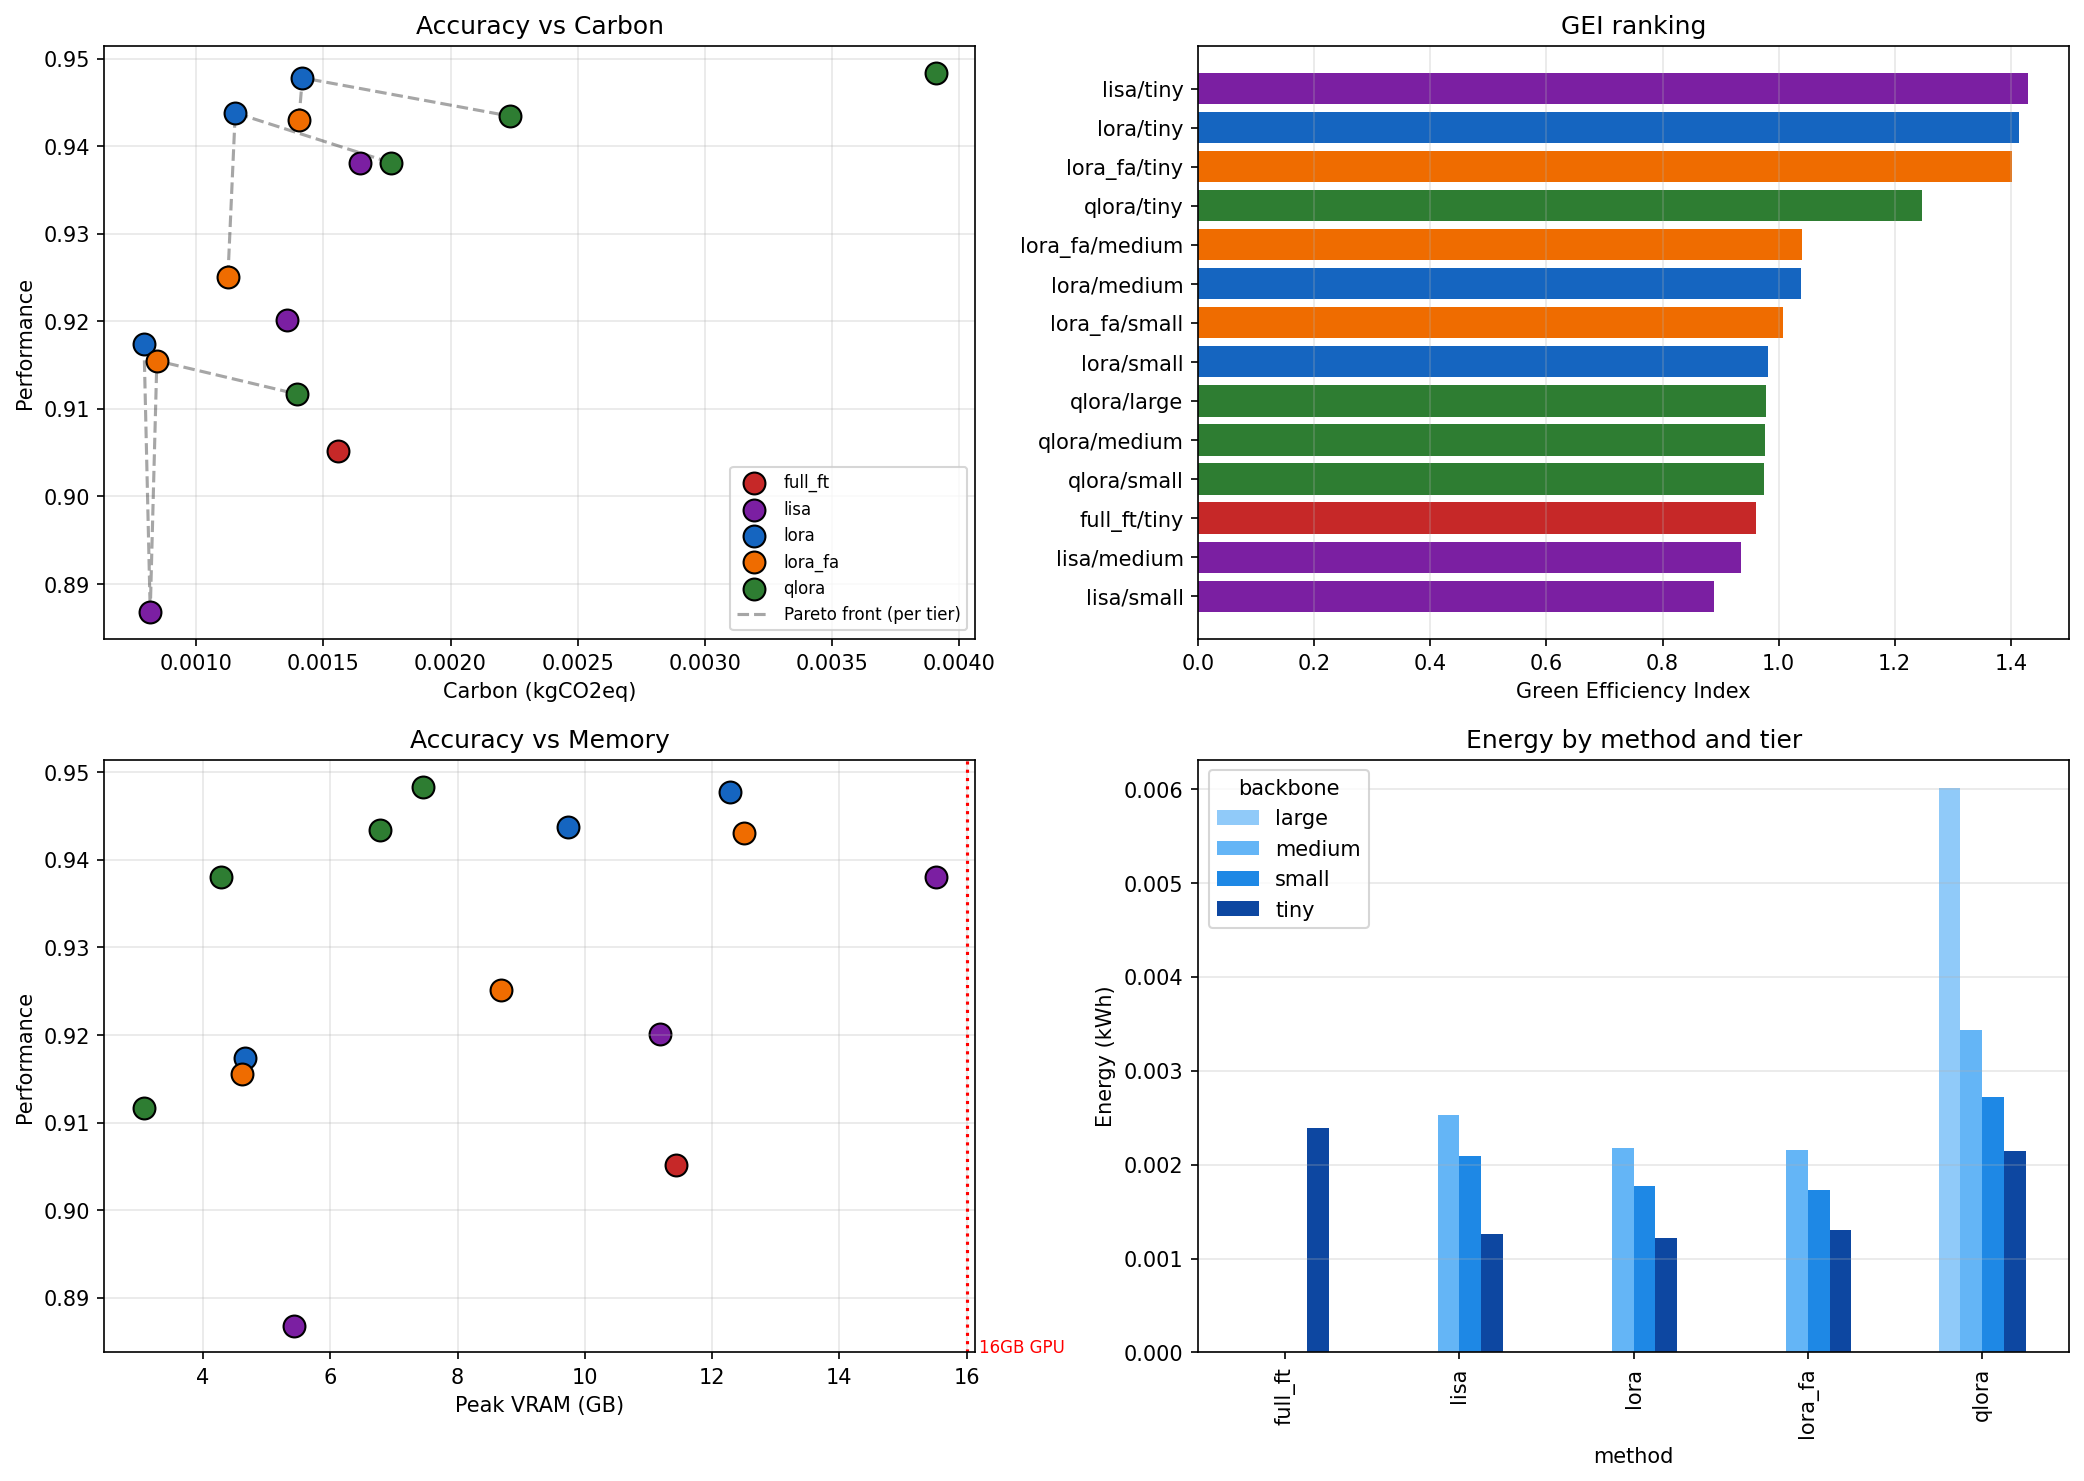

In [15]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

gei = pd.read_csv(RESULTS_DIR / 'aggregated_gei.csv')
pareto = pd.read_csv(RESULTS_DIR / 'pareto_fronts.csv')
MCOLORS = {'full_ft': '#c62828', 'lora': '#1565c0', 'qlora': '#2e7d32',
           'lora_fa': '#ef6c00', 'lisa': '#7b1fa2'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
for m, blk in gei.groupby('method'):
    ax.scatter(blk['carbon_kgco2eq_mean'], blk['accuracy_mean'], s=110,
               label=m, color=MCOLORS.get(m, 'gray'), edgecolor='k', zorder=3)
for lbl, pf in pareto.groupby('front_label'):
    pf = pf.sort_values('carbon_kgco2eq_mean')
    ax.plot(pf['carbon_kgco2eq_mean'], pf['accuracy_mean'], '--', color='k', alpha=.35)
ax.plot([], [], '--', color='k', alpha=.35, label='Pareto front (per tier)')
ax.set_xlabel('Carbon (kgCO2eq)'); ax.set_ylabel('Performance'); ax.set_title('Accuracy vs Carbon')
ax.legend(fontsize=8); ax.grid(alpha=.3)

ax = axes[0, 1]
o = gei.sort_values('gei', ascending=True)
ax.barh([f'{r.method}/{r.backbone}' for r in o.itertuples()], o['gei'],
        color=[MCOLORS.get(m, 'gray') for m in o['method']])
ax.set_xlabel('Green Efficiency Index'); ax.set_title('GEI ranking'); ax.grid(alpha=.3, axis='x')

ax = axes[1, 0]
for m, blk in gei.groupby('method'):
    ax.scatter(blk['peak_mem_gb_mean'], blk['accuracy_mean'], s=110,
               label=m, color=MCOLORS.get(m, 'gray'), edgecolor='k')
ax.axvline(16, ls=':', color='r'); ax.text(16.2, ax.get_ylim()[0], '16GB GPU', color='r', fontsize=8)
ax.set_xlabel('Peak VRAM (GB)'); ax.set_ylabel('Performance'); ax.set_title('Accuracy vs Memory')
ax.grid(alpha=.3)

ax = axes[1, 1]
piv = gei.pivot_table(index='method', columns='backbone', values='energy_kwh_mean')
piv.plot(kind='bar', ax=ax, color=['#90caf9', '#64b5f6', '#1e88e5', '#0d47a1'][:piv.shape[1]])
ax.set_ylabel('Energy (kWh)'); ax.set_title('Energy by method and tier'); ax.grid(alpha=.3, axis='y')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'benchmark_overview.png', dpi=150, bbox_inches='tight')
print('Saved', FIGURES_DIR / 'benchmark_overview.png')

from IPython.display import Image, display as _d
_d(Image(str(FIGURES_DIR / 'benchmark_overview.png')))

In [16]:
import shutil

staging = ROOT / 'export_bundle'
if staging.exists():
    shutil.rmtree(staging)
staging.mkdir(parents=True)

for src in [RAW_DIR, FIGURES_DIR, CONFIG_DIR,
            RESULTS_DIR / 'sweep_raw.csv', RESULTS_DIR / 'aggregated.csv',
            RESULTS_DIR / 'aggregated_scored.csv', RESULTS_DIR / 'aggregated_gei.csv',
            RESULTS_DIR / 'pareto_fronts.csv']:
    if src.is_dir():
        shutil.copytree(src, staging / src.name, dirs_exist_ok=True)
    elif src.exists():
        shutil.copy2(src, staging / src.name)

manifest = {
    'generated_at': time.strftime('%Y-%m-%d %H:%M:%S'),
    'run_mode': RUN_MODE, 'platform': PLATFORM, 'gpu': GPU_NAME,
    'backbones': BACKBONES, 'methods': METHODS, 'tasks': TASKS, 'seeds': SEEDS,
    'train_steps': TRAIN_STEPS, 'batch_size': BATCH_SIZE,
    'grid_carbon_kg_per_kwh': GRID_CARBON_KG_PER_KWH,
    'gei_weights': GEI_WEIGHTS,
    'n_raw_runs': len(list(RAW_DIR.glob('*.json'))),
}
json.dump(manifest, open(staging / 'manifest.json', 'w'), indent=2)

archive = shutil.make_archive(str(ROOT / 'sustainable_peft_benchmark_bundle'), 'zip', staging)
print('Bundle:', archive)
print('Size  :', round(Path(archive).stat().st_size / 1e6, 2), 'MB')
if IN_KAGGLE:
    shutil.copy2(archive, '/kaggle/working/')
    print('\nCopied to /kaggle/working -> download it from the Output panel on the right.')
elif IN_COLAB:
    from google.colab import files
    print('\nRun files.download(archive) in a new cell to download it.')

Bundle: /kaggle/working/peft_bench/sustainable_peft_benchmark_bundle.zip
Size  : 0.23 MB

Copied to /kaggle/working -> download it from the Output panel on the right.


## Troubleshooting

| Symptom | Fix |
|---|---|
| `ImportError` right after Cell 1 | Session -> Restart, then run Cell 1 again with `INSTALL = False` |
| `CUDA out of memory` on every run | Lower `BATCH_SIZE` to 2 and `MAX_SEQ_LEN` to 128 in Cell 2 |
| QLoRA rows all skipped | Your GPU is a P100. Switch Kaggle accelerator to **GPU T4 x2** |
| Dataset download fails on Kaggle | Notebook Settings -> Internet = **ON** |
| Energy is a flat number every run | NVML is missing, so a fixed TDP was used. Only real on a proper GPU runtime |
| Session died mid-sweep | Just re-run Cell 10. Finished runs are skipped automatically |
| `full_ft` rows say `oom` | Expected on medium/large tiers with 16 GB. It is a result, keep it |

## Kaggle vs Colab

| | Kaggle | Colab Free |
|---|---|---|
| GPU | T4 x2 or P100, 16 GB | T4, 16 GB |
| Session length | 12 h | ~90 min idle cutoff |
| Weekly quota | 30 h | vague, throttled |
| Files survive | Yes, in `/kaggle/working` | No, wiped on disconnect |
| Verdict | **Use this for the real sweep** | Fine for `smoke` only |
